<a href="https://colab.research.google.com/github/Saibhossain/Interview-agent/blob/main/LangGraph_powered_multi_agent_system_for_AI_Interview_Simulator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AI Interview Simulator

In [ ]:
!pip install langgraph langchain langchain-community langchain_core
!pip install transformers accelerate sentence-transformers
!pip install faiss-cpu faster-whisper
!pip install gradio pydantic torch pdfplumber python-docx
!pip install faster-whisper faster-whisper pyttsx3
!pip install langchain-text-splitters

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.3/108.3 kB 2.3 MB/s eta 0:00:00
  Attempting uninstall: click
    Found existing installation: click 8.1.8
    Uninstalling click-8.1.8:
      Successfully uninstalled click-8.1.8
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gtts 2.5.4 requires click<8.2,>=7.1, but you have click 8.3.1 which is incompatible.


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
^C


# Phase 1

## basic

In [ ]:
import gradio as gr
import os
import faiss
import pickle
import numpy as np

from pydantic import BaseModel, Field
from typing import List, Optional

from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
from langgraph.graph import StateGraph, END


# =========================
# LOAD EMBEDDING MODEL
# =========================

# Small fast embedding model
embed_model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
def extract_pdf(file_path):
    """
    Extract text from PDF using pdfplumber.
    """

    text = ""

    with pdfplumber.open(file_path) as pdf:

        for page in pdf.pages:

            page_text = page.extract_text()

            if page_text:
                text += page_text + "\n"

    return text

def extract_docx(file_path):
    """
    Extract text from DOCX file.
    """

    doc = docx.Document(file_path)

    text = "\n".join(
        [para.text for para in doc.paragraphs]
    )

    return text


def extract_txt(file_path):
    """
    Extract text from TXT file.
    """

    with open(file_path, "r", encoding="utf-8") as f:
        return f.read()


In [ ]:
def chunk_text(text, chunk_size=600):
    """
    Split text into chunks of specified size.
    """
    chunks = []
    start = 0
    while start < len(text):
        end = start + chunk_size
        chunk = text[start:end]
        chunks.append(chunk)
        start = end
    return chunks

In [ ]:
# =========================
# VECTOR DATABASE CLASS
# =========================

class VectorStore:

    def __init__(self):

        self.index = None
        self.text_chunks = []

    def create_index(self, embeddings):

        dim = embeddings.shape[1]

        self.index = faiss.IndexFlatL2(dim)

        self.index.add(embeddings)

    def save(self):

        os.makedirs("vectordb", exist_ok=True)

        faiss.write_index(self.index, "vectordb/index.faiss")

        with open("vectordb/chunks.pkl", "wb") as f:
            pickle.dump(self.text_chunks, f)

    def load(self):

        self.index = faiss.read_index("vectordb/index.faiss")

        with open("vectordb/chunks.pkl", "rb") as f:
            self.text_chunks = pickle.load(f)


vector_store = VectorStore()

In [ ]:
# Main

def process_document(file):

    if file is None:
        return "Please upload a document."

    file_path = file.name

    # Detect file type

    if file_path.endswith(".pdf"):
        text = extract_pdf(file_path)

    elif file_path.endswith(".docx"):
        text = extract_docx(file_path)

    elif file_path.endswith(".txt"):
        text = extract_txt(file_path)

    else:
        return "Unsupported file type."

    # Chunk text

    chunks = chunk_text(text)

    # Create embeddings

    embeddings = embed_model.encode(chunks)

    # Store

    vector_store.text_chunks = chunks

    vector_store.create_index(embeddings)

    vector_store.save()

    return f"Document processed.\nChunks created: {len(chunks)}"


# =========================
# UI
# =========================

with gr.Blocks() as demo:

    gr.Markdown("# 📄 Phase-1 Document Vector Database Builder")

    file = gr.File(label="Upload PDF / DOCX / TXT")

    btn = gr.Button("Process Document")

    output = gr.Textbox()

    btn.click(
        process_document,
        inputs=file,
        outputs=output
    )

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8529cccdccb871cd6c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## With LangChain's text splitters and imporve chunking

how it works:
1. separators=["\n\n", "\n", " ", ""]: Instead of slicing blindly at 600 characters, it looks for the natural breaks in the CV. If "Experience" is separated from "Education" by a double space (\n\n), the chunker will safely split them there, keeping the sections isolated.

2. chunk_overlap=150: This is the most crucial fix for your "spilled into two parts" issue. If a project description is slightly too long and has to be split, the last 150 characters of Chunk A are duplicated at the start of Chunk B. This ensures that the LLM reading Chunk B still has the context of what project is being discussed.

3. Larger chunk_size: I bumped the size from 600 to 800. A CV is dense. 600 characters is barely enough to capture a job title, date, and two bullet points. 800-1000 is usually the sweet spot for dense resumes.





In [ ]:

import os
import pickle
import pdfplumber
import faiss
import numpy as np

from sentence_transformers import SentenceTransformer
from langchain_text_splitters import RecursiveCharacterTextSplitter

# =========================
# LOAD EMBEDDING MODEL
# =========================

embed_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

# =========================
# CHUNKING LOGIC
# =========================
def chunk_text_advanced(text, chunk_size=800, overlap=150):
    """
    Splits text semantically based on paragraphs and bullet points,
    leaving an overlap to ensure context (like a job title) isn't lost
    between two chunks.
    """
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=overlap,
        length_function=len,
        # This is the magic. It tries to split at the double newline (new CV section),
        # then single newline (bullet point), then space.
        separators=["\n\n", "\n", " ", ""]
    )

    # split_text returns a list of strings
    chunks = text_splitter.split_text(text)
    return chunks

# =========================
# UPGRADED PROCESS DOCUMENT ⭐
# =========================
def process_document(file):
    if file is None:
        return "Upload file first."

    path = file.name

    # Extract text based on file type
    if path.endswith(".pdf"):
        text = extract_pdf(path)
    elif path.endswith(".docx"):
        text = extract_docx(path)
    elif path.endswith(".txt"):
        text = extract_txt(path)
    else:
        return "Unsupported format."

    # 1. Use the advanced chunker
    chunks = chunk_text_advanced(text)

    # 2. Check if text extraction actually worked before embedding
    if not chunks:
        return "Error: Could not extract text from document."

    # 3. Create embeddings
    embeddings = embed_model.encode(chunks)

    # 4. Save to Vector Store
    vector_store.text_chunks = chunks
    vector_store.create(embeddings)
    vector_store.save()

    return f"Vector DB successfully built.\nCreated {len(chunks)} semantic chunks."


 # =========================
# MAIN FUNCTION
# =========================
def main():
    class FileObject:
        """Simple wrapper to mimic uploaded file object"""
        def __init__(self, path):
            self.name = path

    # Example file path
    file_path = "/content/Ai Engineer Job-Cv (5).pdf"

    if not os.path.exists(file_path):
        print("File not found. Please add sample.txt in this folder.")
        return

    # Create file-like object
    file = FileObject(file_path)

    # Process document
    result = process_document(file)

    # Show output
    print("\n===== OUTPUT =====")
    print(result)


# =========================
# RUN PROGRAM
# =========================
if __name__ == "__main__":
    main()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



===== OUTPUT =====
Vector DB successfully built.
Created 14 semantic chunks.


# Phase 2
Semantic Search Retriever (RAG Core)

In [ ]:
# =========================
# VECTOR STORE
# =========================

class VectorStore:

    def __init__(self):

        self.index = None
        self.text_chunks = []

    def create(self, embeddings):

        dim = embeddings.shape[1]

        self.index = faiss.IndexFlatL2(dim)

        self.index.add(embeddings)

    def save(self):

        os.makedirs("vectordb", exist_ok=True)

        faiss.write_index(self.index, "vectordb/index.faiss")

        with open("vectordb/chunks.pkl", "wb") as f:
            pickle.dump(self.text_chunks, f)

    def load(self):

        if not os.path.exists("vectordb/index.faiss"):
            return False

        self.index = faiss.read_index("vectordb/index.faiss")

        with open("vectordb/chunks.pkl", "rb") as f:
            self.text_chunks = pickle.load(f)

        return True

    def search(self, query, k=3):

        query_vec = embed_model.encode([query])

        D, I = self.index.search(np.array(query_vec), k)

        results = [self.text_chunks[i] for i in I[0]]

        return results


vector_store = VectorStore()

In [ ]:
def process_document(file):

    if file is None:
        return "Upload file first."

    path = file.name

    if path.endswith(".pdf"):
        text = extract_pdf(path)

    elif path.endswith(".docx"):
        text = extract_docx(path)

    elif path.endswith(".txt"):
        text = extract_txt(path)

    else:
        return "Unsupported format."

    chunks = chunk_text(text)

    embeddings = embed_model.encode(chunks)

    vector_store.text_chunks = chunks
    vector_store.create(embeddings)
    vector_store.save()

    return f"Vector DB built.\nChunks: {len(chunks)}"

In [ ]:
# RETRIEVER
# =========================

def search_query(query):

    loaded = vector_store.load()

    if not loaded:
        return "Vector DB not found. Upload document first."

    results = vector_store.search(query, k=3)

    return "\n\n---\n\n".join(results)

In [ ]:
# =========================
# UI
# =========================

with gr.Blocks() as demo:

    gr.Markdown("# 📄🔎 Phase-2 Semantic Search Retriever")

    gr.Markdown("## Step-1 Upload Document")

    file = gr.File()

    build_btn = gr.Button("Build Vector DB")

    build_out = gr.Textbox()

    build_btn.click(
        process_document,
        inputs=file,
        outputs=build_out
    )

    gr.Markdown("## Step-2 Ask Question")

    query = gr.Textbox(label="Search Query")

    search_btn = gr.Button("Search")

    result_box = gr.Textbox(lines=12)

    search_btn.click(
        search_query,
        inputs=query,
        outputs=result_box
    )


demo.launch()

NameError: name 'search_query' is not defined

# phase 3
LLM Interview Question Generator (RAG + Local LLM)

In [ ]:
# =========================
# LOAD LOCAL LLM
# =========================

MODEL_ID = "Qwen/Qwen2-1.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    device_map="cpu",
    low_cpu_mem_usage=True
)

llm_pipeline = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=200,
    temperature=0.7
)


def generate_llm(prompt):

    output = llm_pipeline(prompt)[0]["generated_text"]

    return output[len(prompt):]


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


In [ ]:
# =========================
# INTERVIEW QUESTION GENERATOR ⭐
# =========================

def generate_question(role):

    if not vector_store.load():
        return "Upload document first."

    # retrieve knowledge
    context_chunks = vector_store.search(role, k=4)

    context = "\n".join(context_chunks)

    prompt = f"""
You are a senior technical interviewer.

Role: {role}

Use the following knowledge context to generate ONE realistic interview question.

Context:
{context}

Only output the question.
"""

    question = generate_llm(prompt)

    return question

In [ ]:
with gr.Blocks() as demo:

    gr.Markdown("# 🤖 Phase-3 RAG Interview Question Generator")

    gr.Markdown("## Step-1 Build Knowledge Base")

    file = gr.File()

    build_btn = gr.Button("Build Vector DB")

    build_out = gr.Textbox()

    build_btn.click(process_document, file, build_out)

    gr.Markdown("## Step-2 Semantic Search")

    query = gr.Textbox()

    search_btn = gr.Button("Search")

    result = gr.Textbox(lines=10)

    search_btn.click(search_query, query, result)

    gr.Markdown("## ⭐ Step-3 Generate Interview Question")

    role = gr.Dropdown(
        ["AI Engineer", "ML Engineer", "Backend Engineer"]
    )

    gen_btn = gr.Button("Generate Question")

    qbox = gr.Textbox()

    gen_btn.click(generate_question, role, qbox)


demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a9cf4d0cdc9f9146be.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# phase 4

Stateful Interview Agent using LangGraph

In [ ]:
# =========================
# STATE
# =========================

from pydantic import BaseModel, Field
from typing import List, Optional
from langgraph.graph import END


class InterviewState(BaseModel):

    role: str

    history: List[str] = Field(default_factory=list)

    question: Optional[str] = None
    answer: Optional[str] = None

    evaluation: Optional[str] = None
    retrieved_context: List[str] = Field(default_factory=list)

    difficulty: str = "medium"

    step_count: int = 0
    finished: bool = False

In [ ]:
# =========================
# AGENTS
# =========================

def question_agent(state):

    context_chunks = vector_store.search(state.role)

    context = "\n".join(context_chunks)

    memory = "\n".join(state.history[-4:])

    prompt = f"""
You are senior interviewer.

Role: {state.role}

Difficulty: {state.difficulty}

Previous context:
{memory}

Knowledge:
{context}

Ask ONE interview question.
"""

    q = llm(prompt)

    state.question = q

    return state


def evaluation_agent(state):

    prompt = f"""
Evaluate candidate answer.

Question:
{state.question}

Answer:
{state.answer}

Give score out of 10 and short feedback.
"""

    ev = llm(prompt)

    state.evaluation = ev

    return state


def memory_agent(state):

    state.history.append("Q:" + state.question)
    state.history.append("A:" + state.answer)
    state.history.append("E:" + state.evaluation)

    return state


def difficulty_agent(state):

    prompt = f"""
Based on evaluation decide difficulty:

{state.evaluation}

Return easy or medium or hard.
"""

    d = llm(prompt)

    state.difficulty = d.strip()

    return state


def router_agent(state):

    state.qn += 1

    if state.qn >= 5:
        state.done = True

    return state



#------------------------------
def question_node(state):

    context = "\n".join(state.retrieved_context)

    memory = "\n".join(state.history[-6:])

    prompt = f"""
You are senior interviewer.

Role: {state.role}
Difficulty: {state.difficulty}

Context:
{context}

Conversation memory:
{memory}

Ask ONE interview question.
"""

    state.question = llm(prompt)

    return state


def retrieval_node(state):

    ctx = vector_store.search(state.role, k=3)

    state.retrieved_context = ctx

    return state


def evaluation_node(state):

    prompt = f"""
Evaluate answer.

Question:
{state.question}

Answer:
{state.answer}

Give score out of 10 and feedback.
"""

    state.evaluation = llm(prompt)

    return state

def reflection_node(state):

    state.history.append("Q:" + state.question)
    state.history.append("A:" + state.answer)
    state.history.append("E:" + state.evaluation)

    prompt = f"""
Based on evaluation decide next difficulty:

{state.evaluation}

Return easy medium or hard.
"""

    state.difficulty = llm(prompt).strip()

    state.step_count += 1

    if state.step_count >= 5:
        state.finished = True

    return state




def router(state):

    if state.finished:
        return END

    return "question"

In [ ]:
# =========================
# GRAPH BUILD
# =========================
from langgraph.graph import StateGraph
from langgraph.checkpoint.memory import MemorySaver

builder = StateGraph(InterviewState)

builder.add_node("question", question_node)
builder.add_node("retrieve", retrieval_node)
builder.add_node("evaluate", evaluation_node)
builder.add_node("reflect", reflection_node)

builder.set_entry_point("question")

# after question → wait user input externally

# parallel execution
builder.add_edge("question", "retrieve")
builder.add_edge("question", "evaluate")

# fan-in
builder.add_edge("retrieve", "reflect")
builder.add_edge("evaluate", "reflect")

# loop
builder.add_conditional_edges(
    "reflect",
    router
)

memory = MemorySaver()

graph = builder.compile(checkpointer=memory)

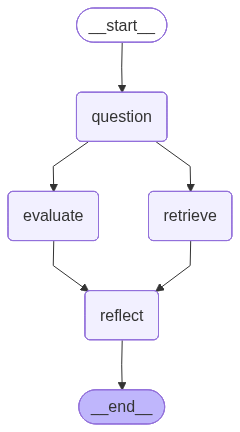

In [ ]:
graph

In [ ]:
CONFIG = {"configurable": {"thread_id": "interview1"}}

STATE = None


def start(role):

    global STATE

    STATE = InterviewState(role=role)

    STATE = graph.invoke(STATE, config=CONFIG)

    return STATE.question


def submit_answer(ans):

    global STATE

    STATE.answer = ans

    STATE = graph.invoke(STATE, config=CONFIG)

    if STATE.finished:
        return "Interview Finished"

    return STATE.question

In [ ]:
with gr.Blocks() as demo:

    gr.Markdown("# 🧠 Phase-4 LangGraph Interview Agent")

    role = gr.Dropdown(
        ["AI Engineer", "ML Engineer", "Backend Engineer"]
    )

    start_btn = gr.Button("Start Interview")

    qbox = gr.Textbox(label="AI Question")

    answer = gr.Textbox(label="Your Answer")

    submit = gr.Button("Submit")

    start_btn.click(start, role, qbox)

    submit.click(submit_answer, answer, qbox)


demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4f3c08b9ee64817f23.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
